# Análise e Preparação de Dados para Predição de Renda com Machine Learning

**Autor:** André Douglas da Silva Cruz

## Contexto do Problema

A previsão de renda é um problema clássico de classificação em Machine Learning, amplamente utilizado em estudos socioeconômicos e análises demográficas.

Neste projeto será utilizado o conjunto de dados Adult Census Income, disponibilizado pela UCI Machine Learning Repository, contendo informações demográficas, educacionais e ocupacionais de indivíduos coletadas a partir do censo norte-americano de 1994.

O problema consiste em determinar se um indivíduo possui renda anual superior ou inferior a 50 mil dólares com base em características como idade, escolaridade, ocupação, estado civil, jornada de trabalho e demais informações disponíveis na base de dados.

## Objetivo

Este projeto tem como objetivo analisar o conjunto de dados Adult Census Income e preparar uma base de dados adequada para modelos de Machine Learning capazes de prever se um indivíduo possui renda anual superior ou inferior a 50 mil dólares, utilizando características demográficas, educacionais e ocupacionais.

Para isso, serão realizadas etapas de Análise Exploratória de Dados (EDA), Engenharia de Atributos (Feature Engineering) com apoio de IA Generativa e técnicas de pré-processamento voltadas à preparação dos dados para modelagem preditiva.

## Objetivos Específicos

- Avaliar a qualidade e a consistência dos dados.
- Identificar valores ausentes, distribuições e possíveis outliers.
- Investigar relações entre as variáveis e a renda dos indivíduos.
- Desenvolver novos atributos com potencial preditivo.
- Aplicar técnicas de preparação de dados para utilização em algoritmos de Machine Learning.

## Variável Alvo

A variável alvo do estudo é `income`, composta pelas seguintes classes:

- `<=50K`: renda anual menor ou igual a 50 mil dólares.
- `>50K`: renda anual superior a 50 mil dólares.

## Importação das Bibliotecas



In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Configuração visual dos gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# 1. Análise Exploratória dos Dados (EDA)

## 1.1 Importação e Qualidade dos Dados

In [7]:
colunas = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education_num',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital_gain',
    'capital_loss',
    'hours_per_week',
    'native_country',
    'income'
]

df = pd.read_csv(
    'adult.data',
    names=colunas,
    na_values='?',
    skipinitialspace=True
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
df.shape

(32561, 15)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [10]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

### Análise dos Resultados

A análise da estrutura da base revelou a presença de 32.561 registros distribuídos em 15 variáveis, sendo 6 numéricas e 9 categóricas.

Foram identificados valores ausentes nas variáveis `workclass`, `occupation` e `native_country`, originalmente representados pelo símbolo "?" no dataset. As demais variáveis não apresentaram dados faltantes.

A identificação desses registros é fundamental para definir estratégias adequadas de tratamento dos dados nas etapas seguintes, garantindo maior qualidade e consistência para as análises e modelos preditivos.

## 1.2 Limpeza Inicial

In [11]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [12]:
round(df['income'].value_counts(normalize=True) * 100, 2)

income
<=50K    75.92
>50K     24.08
Name: proportion, dtype: float64

### Análise da Variável Alvo

A variável alvo `income` possui duas categorias de renda:

- `<=50K`: renda anual de até 50 mil dólares.
- `>50K`: renda anual acima de 50 mil dólares.

A distribuição das classes mostrou que aproximadamente 75,92% dos registros pertencem à categoria `<=50K`, enquanto 24,08% pertencem à categoria `>50K`.

Esse resultado indica um desbalanceamento moderado entre as classes, com predominância de indivíduos na faixa de menor renda. Embora não seja um desbalanceamento extremo, essa característica deve ser considerada nas etapas futuras de modelagem e avaliação dos modelos de Machine Learning.

In [13]:
df['income_bin'] = df['income'].map({
    '<=50K': 0,
    '>50K': 1
})

df[['income', 'income_bin']].head()

,income,income_bin
0,<=50K,0
1,<=50K,0
2,<=50K,0
3,<=50K,0
4,<=50K,0


A coluna `income_bin` foi criada para representar numericamente a variável alvo do problema de classificação.

Nessa codificação, o valor 0 corresponde à classe `<=50K` e o valor 1 corresponde à classe `>50K`.

A transformação facilita a utilização da variável alvo em algoritmos de Machine Learning, que geralmente operam com valores numéricos.

In [14]:
(df.isnull().sum() / len(df) * 100).round(2)

age               0.00
workclass         5.64
fnlwgt            0.00
education         0.00
education_num     0.00
marital_status    0.00
occupation        5.66
relationship      0.00
race              0.00
sex               0.00
capital_gain      0.00
capital_loss      0.00
hours_per_week    0.00
native_country    1.79
income            0.00
income_bin        0.00
dtype: float64

### Tratamento dos Valores Ausentes

Foram identificados valores ausentes nas variáveis `workclass` (5,64%), `occupation` (5,66%) e `native_country` (1,79%).

Optou-se por manter os registros e realizar o tratamento dos valores ausentes durante a etapa de pré-processamento. A remoção desses registros poderia resultar em perda de informações potencialmente relevantes para a modelagem.

Como as variáveis afetadas são categóricas, será utilizada posteriormente a estratégia de imputação pela categoria mais frequente (`most_frequent`), conforme recomendado para esse tipo de variável.

## 1.3 Distribuições

In [15]:
df[['age',
    'hours_per_week',
    'capital_gain',
    'capital_loss',
    'education_num']].describe()

,age,hours_per_week,capital_gain,capital_loss,education_num
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,40.437456,1077.648844,87.303830,10.080679
std,13.640433,12.347429,7385.292085,402.960219,2.572720
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,40.000000,0.000000,0.000000,9.000000
50%,37.000000,40.000000,0.000000,0.000000,10.000000
75%,48.000000,45.000000,0.000000,0.000000,12.000000
max,90.000000,99.000000,99999.000000,4356.000000,16.000000


### Análise Estatística Inicial

A análise descritiva das variáveis numéricas revelou diferenças importantes em suas distribuições.

As variáveis `age`, `hours_per_week` e `education_num` apresentaram médias e medianas relativamente próximas, sugerindo distribuições mais equilibradas.

Por outro lado, as variáveis `capital_gain` e `capital_loss` apresentaram medianas iguais a zero e valores máximos muito superiores às médias, indicando forte concentração de registros com valor zero e a presença de observações extremas. Esse comportamento sugere distribuições assimétricas, que serão investigadas com maior detalhe nas próximas análises gráficas.

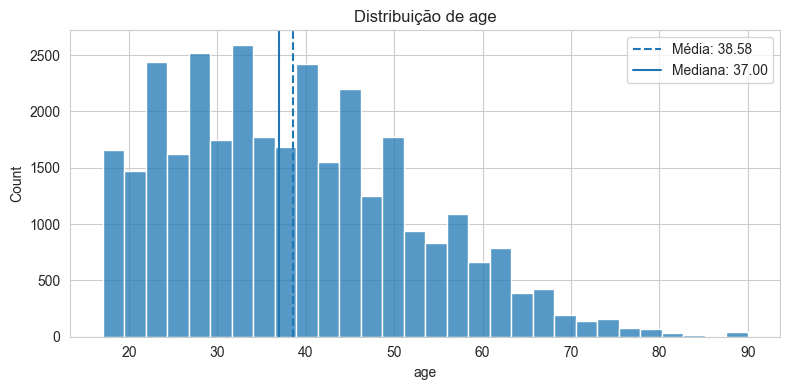

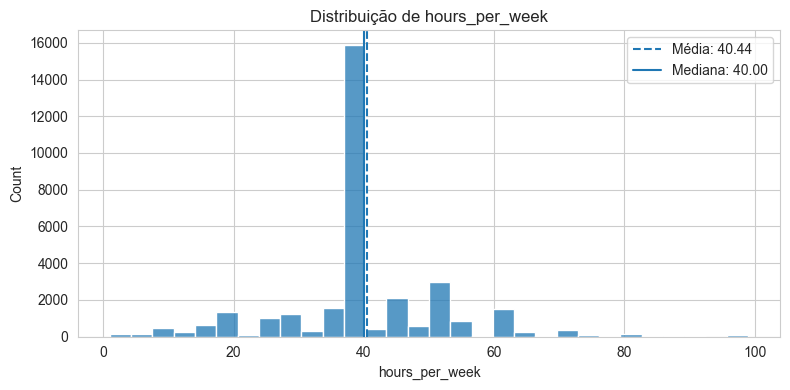

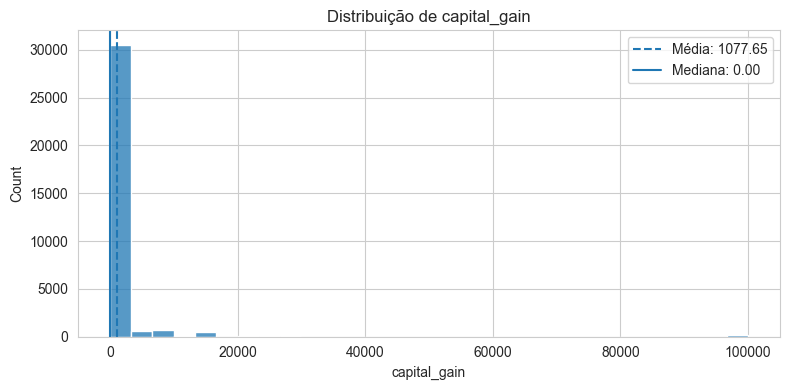

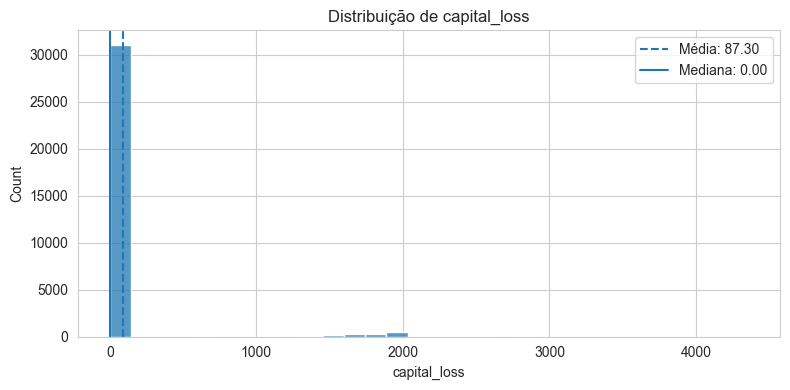

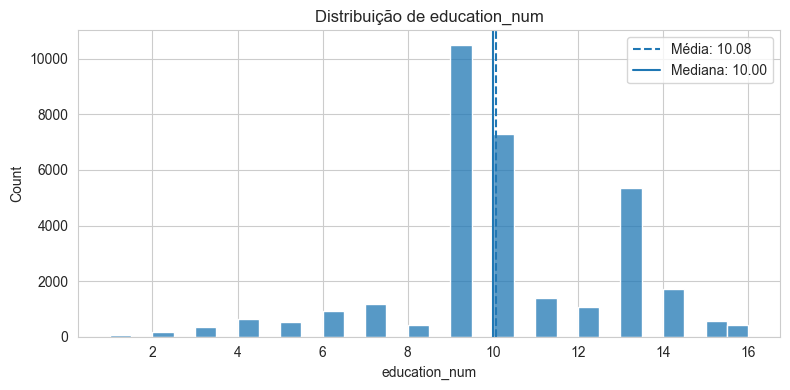

In [16]:
numericas = [
    'age',
    'hours_per_week',
    'capital_gain',
    'capital_loss',
    'education_num'
]

for coluna in numericas:

    plt.figure(figsize=(8,4))

    sns.histplot(df[coluna], bins=30)

    plt.axvline(
        df[coluna].mean(),
        linestyle='--',
        label=f'Média: {df[coluna].mean():.2f}'
    )

    plt.axvline(
        df[coluna].median(),
        linestyle='-',
        label=f'Mediana: {df[coluna].median():.2f}'
    )

    plt.title(f'Distribuição de {coluna}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [17]:
df[['age',
    'hours_per_week',
    'capital_gain',
    'capital_loss',
    'education_num']].skew()

age                0.558743
hours_per_week     0.227643
capital_gain      11.953848
capital_loss       4.594629
education_num     -0.311676
dtype: float64

### Análise da Assimetria (Skewness)
Os valores de assimetria confirmam o padrão observado na análise estatística inicial. A variável `capital_gain` apresentou assimetria extremamente alta (**11,95**), e `capital_loss` também se mostrou fortemente assimétrica (**4,59**) — ambas muito acima do intervalo geralmente considerado de distribuição aproximadamente simétrica (entre -0,5 e 0,5). Esse resultado é coerente com o fato de que a mediana de ambas as variáveis é zero, com a grande maioria dos indivíduos sem ganhos ou perdas de capital, enquanto uma pequena parcela concentra valores extremamente altos (até 99.999 em `capital_gain`), o que distorce fortemente a distribuição para a direita.

A variável `age` apresentou assimetria positiva moderada (**0,56**), indicando uma cauda discretamente mais longa em direção às idades mais avançadas — coerente com a média (38,6) sendo levemente superior à mediana (37).

Já `hours_per_week` (**0,23**) e `education_num` (**-0,31**) apresentaram assimetria próxima de zero, o que indica distribuições relativamente equilibradas. O valor levemente negativo de `education_num` sugere uma cauda discreta em direção aos níveis educacionais mais baixos, mas sem distorção relevante.

Esse diagnóstico reforça uma decisão prática para etapas futuras: `capital_gain` e `capital_loss` são as candidatas naturais a transformações como log (`np.log1p`) caso algum modelo sensível à distribuição dos dados (como Regressão Logística) seja usado na modelagem, enquanto `age`, `hours_per_week` e `education_num` podem ser utilizadas em sua escala original sem necessidade de tratamento adicional de assimetria.


## 1.4 Outliers

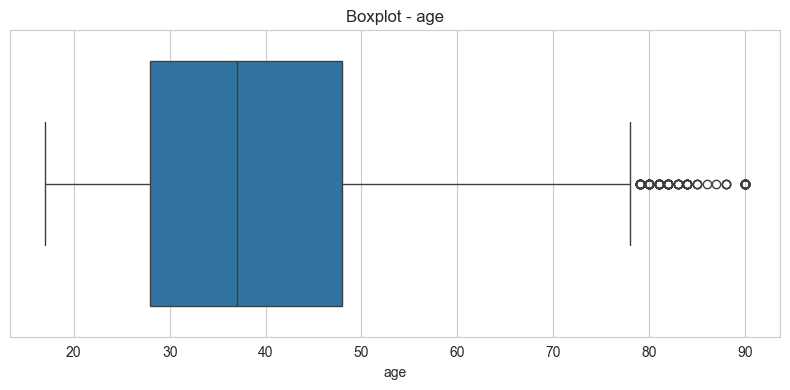

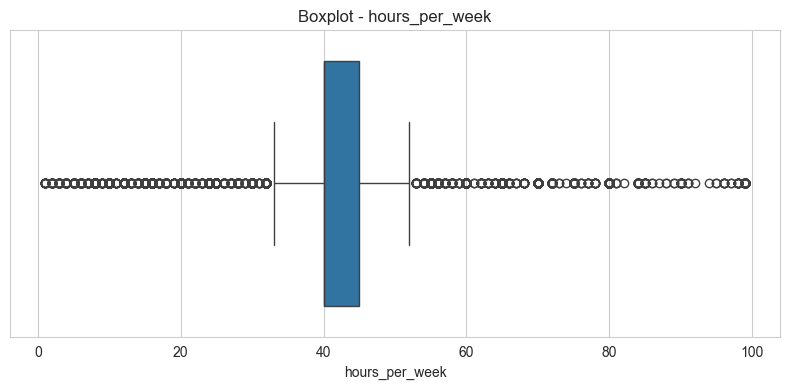

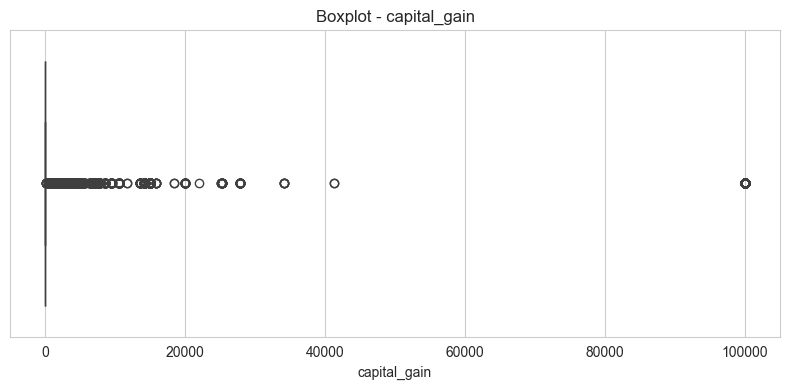

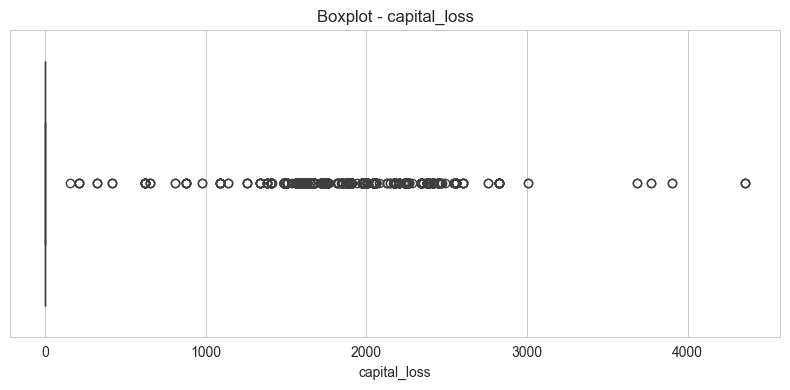

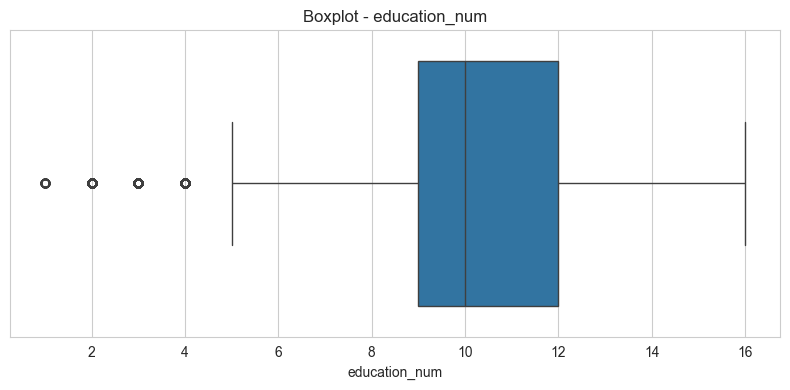

In [18]:
numericas = [
    'age',
    'hours_per_week',
    'capital_gain',
    'capital_loss',
    'education_num'
]

for coluna in numericas:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[coluna])

    plt.title(f'Boxplot - {coluna}')

    plt.tight_layout()
    plt.show()

In [19]:
def percentual_outliers(serie):

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = serie[
        (serie < limite_inferior) |
        (serie > limite_superior)
    ]

    return round(len(outliers) / len(serie) * 100, 2)

for coluna in numericas:
    print(coluna, percentual_outliers(df[coluna]), "%")

age 0.44 %
hours_per_week 27.66 %
capital_gain 8.33 %
capital_loss 4.67 %
education_num 3.68 %


Análise dos Resultados

A análise dos boxplots e do percentual de observações classificadas como outliers permitiu identificar comportamentos distintos entre as variáveis numéricas do conjunto de dados.

A variável age apresentou apenas 0,44% de observações consideradas outliers, indicando baixa ocorrência de valores extremos. Os registros identificados correspondem principalmente a indivíduos com idade mais avançada, representando situações plausíveis e compatíveis com o contexto da pesquisa.

A variável hours_per_week apresentou o maior percentual de outliers (27,66%). Esse resultado sugere a existência de um número significativo de indivíduos com jornadas de trabalho muito superiores àquelas observadas para a maior parte da população. Como essas observações podem estar diretamente relacionadas ao nível de renda dos indivíduos, sua remoção poderia eliminar informações relevantes para a modelagem preditiva.

As variáveis capital_gain (8,33%) e capital_loss (4,67%) apresentaram distribuições fortemente assimétricas, caracterizadas pela predominância de valores iguais a zero e pela presença de poucos registros com valores elevados. Esse comportamento é esperado para variáveis financeiras e reflete características reais da população analisada.

Por sua vez, a variável education_num apresentou 3,68% de observações classificadas como outliers, indicando a existência de níveis educacionais menos frequentes na amostra, sem evidências de inconsistências nos dados.

De modo geral, os valores identificados como outliers representam características legítimas dos indivíduos e possuem potencial relevância para a previsão da renda. Dessa forma, optou-se por manter todas as observações na base de dados, evitando a perda de informações que podem contribuir para o desempenho dos modelos de Machine Learning.

# 1.5 Relação das Variáveis com a Renda

## 1.5.1 Idade por Faixa de Renda

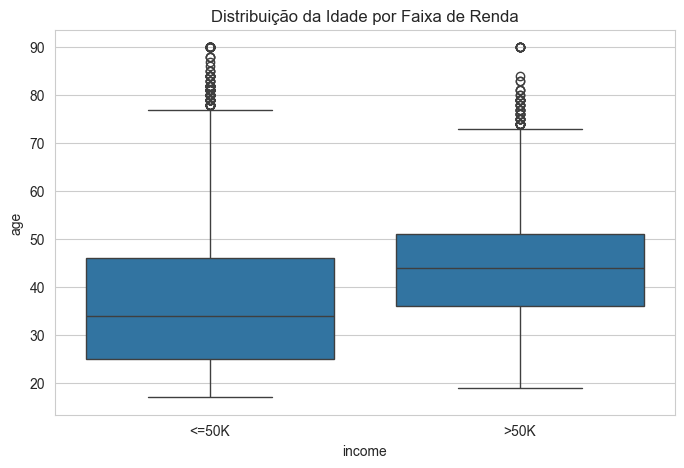

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='income',
    y='age'
)

plt.title('Distribuição da Idade por Faixa de Renda')
plt.show()

## 1.5.2 Horas Trabalhadas por Faixa de Renda

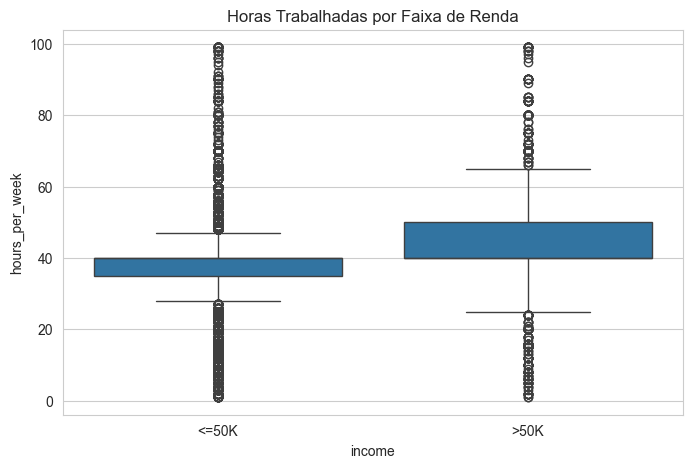

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='income',
    y='hours_per_week'
)

plt.title('Horas Trabalhadas por Faixa de Renda')
plt.show()

## 1.5.3 Escolaridade por Faixa de Renda

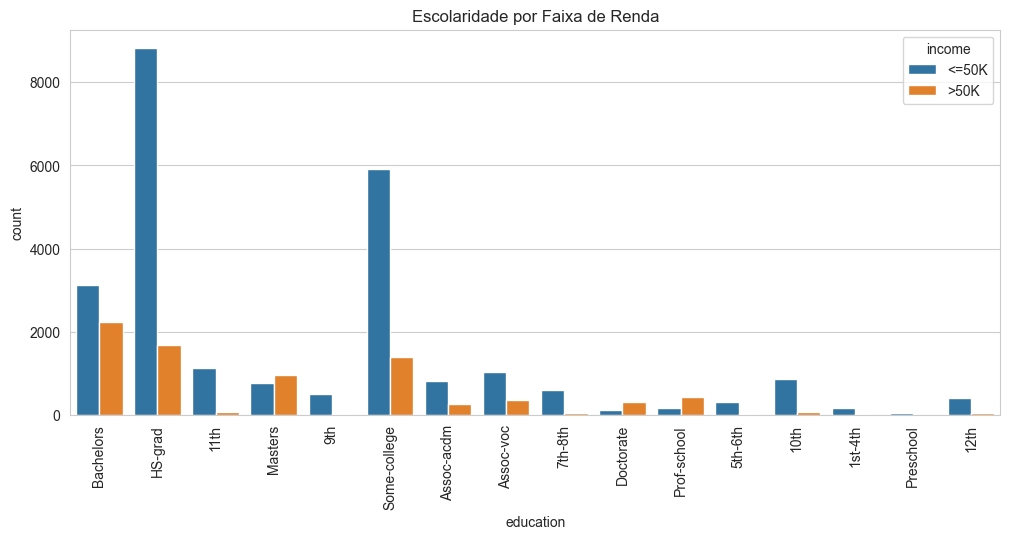

In [22]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='education',
    hue='income'
)

plt.xticks(rotation=90)
plt.title('Escolaridade por Faixa de Renda')
plt.show()

## 1.5.4 Ocupação por Faixa de Renda


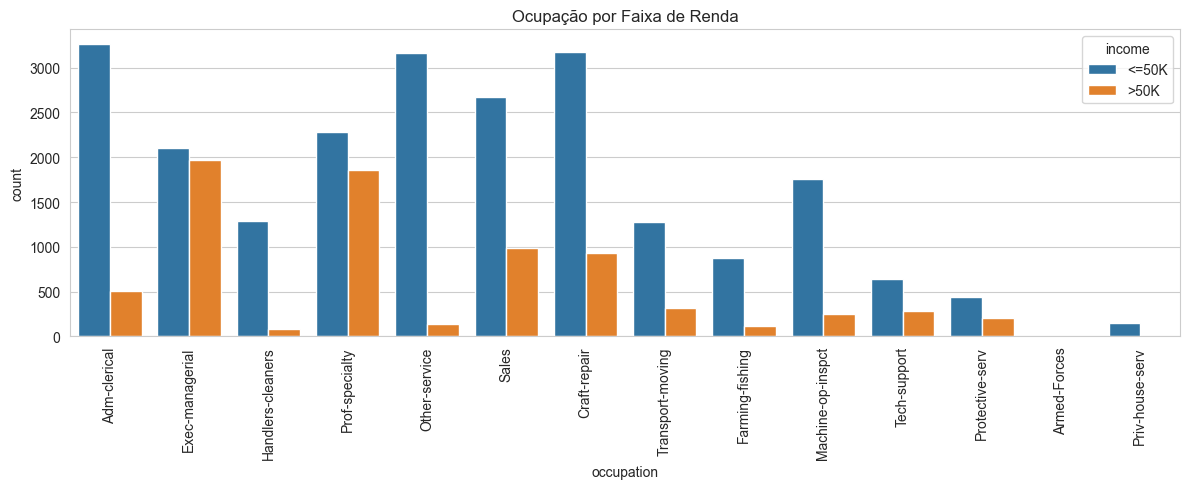

In [23]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='occupation',
    hue='income'
)

plt.xticks(rotation=90)
plt.title('Ocupação por Faixa de Renda')
plt.tight_layout()
plt.show()


### Análise

A análise por ocupação revelou diferenças expressivas na proporção de indivíduos com renda superior a 50 mil dólares. A categoria `Exec-managerial` apresentou a maior proporção, com **48,4%** dos seus indivíduos na faixa `>50K` — quase metade do grupo —, seguida por `Prof-specialty` (34,3%) e `Protective-serv` (32,5%). Esse padrão é coerente com cargos que tipicamente exigem maior qualificação formal ou nível de responsabilidade.

No extremo oposto, `Priv-house-serv` apresentou apenas **0,67%** de indivíduos com renda superior a 50 mil dólares — ou seja, praticamente toda a categoria está concentrada na faixa `<=50K` —, seguida por `Other-service` (4,2%) e `Handlers-cleaners` (6,3%).

A amplitude entre o maior e o menor valor (de 0,67% a 48,4%) evidencia que `occupation` é uma das variáveis categóricas com maior poder discriminativo sobre a renda observadas neste estudo, reforçando o padrão já identificado para escolaridade (Seção 1.5.3). Isso sugere que `occupation` carrega informação complementar — e não redundante — à de `education`, já que combina nível de formação com o tipo de atividade exercida.


## 1.5.5 Estado Civil por Faixa de Renda


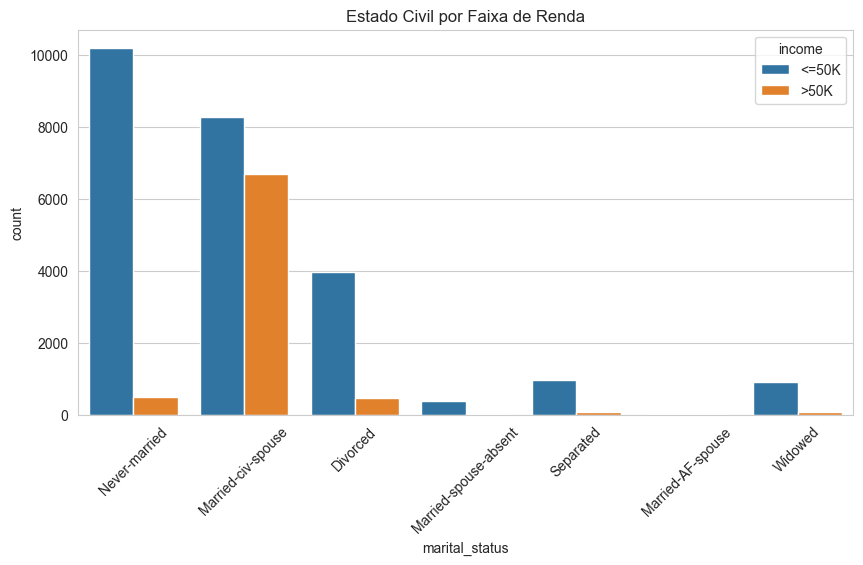

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='marital_status',
    hue='income'
)

plt.xticks(rotation=45)
plt.title('Estado Civil por Faixa de Renda')
plt.show()

### Análise dos Resultados

Observou-se que os indivíduos pertencentes à categoria de renda superior a 50 mil dólares apresentaram média de idade de aproximadamente 44 anos, enquanto aqueles com renda igual ou inferior a 50 mil dólares apresentaram média próxima de 37 anos. Esse resultado indica maior concentração de indivíduos mais experientes na faixa de renda mais elevada.

Em relação às horas trabalhadas por semana, verificou-se média de aproximadamente 45 horas para o grupo de maior renda e 39 horas para o grupo de menor renda, sugerindo associação positiva entre carga horária de trabalho e rendimento.

A análise da escolaridade revelou diferenças expressivas entre as categorias de renda. Níveis educacionais mais elevados, como Bachelor's, Master's, Doctorate e Prof-school, apresentaram participação proporcionalmente maior entre os indivíduos de renda superior a 50 mil dólares. Por outro lado, níveis educacionais mais baixos concentraram predominantemente indivíduos na faixa de renda igual ou inferior a 50 mil dólares.

Também foram observadas diferenças relevantes em relação ao estado civil. A categoria `Married-civ-spouse` apresentou elevada participação na faixa de renda superior a 50 mil dólares, enquanto a categoria `Never-married` concentrou principalmente indivíduos pertencentes à faixa de menor renda.

De forma geral, os resultados indicam que idade, escolaridade, jornada de trabalho e estado civil estão entre as características que apresentaram diferenças mais evidentes entre os grupos de renda analisados.

# 1.6 Correlação entre Variáveis Numéricas

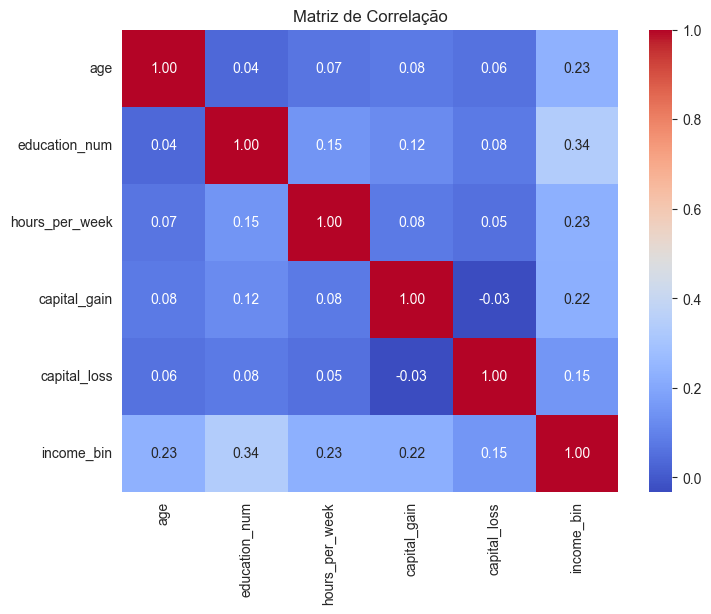

In [25]:
corr = df[
    [
        'age',
        'education_num',
        'hours_per_week',
        'capital_gain',
        'capital_loss',
        'income_bin'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação')
plt.show()

In [26]:
corr['income_bin'].sort_values(ascending=False)

income_bin        1.000000
education_num     0.335154
age               0.234037
hours_per_week    0.229689
capital_gain      0.223329
capital_loss      0.150526
Name: income_bin, dtype: float64

### Análise dos Resultados

Observou-se que a variável **education_num** apresentou a maior correlação positiva com a renda (0,34), indicando ser a característica numérica mais associada à variável alvo entre as analisadas.

As variáveis **age** (0,23), **hours_per_week** (0,23) e **capital_gain** (0,22) apresentaram correlações positivas de menor intensidade, sugerindo associações moderadas com os níveis de renda observados na base de dados.

A variável **capital_loss** apresentou a menor correlação com a renda (0,15), indicando uma relação mais fraca quando comparada às demais variáveis numéricas avaliadas.

De forma geral, nenhuma variável apresentou correlação elevada de maneira isolada, evidenciando que a renda é influenciada por múltiplos fatores. Ainda assim, os resultados apontam a escolaridade como a característica numérica mais associada à renda entre os atributos analisados.

# 2. Engenharia de Atributos (Feature Engineering)



## 2.0 Consulta à IA Generativa

### Análise — Aplicação do Checklist

A IA Generativa sugeriu cinco potenciais atributos para auxiliar na predição da renda dos indivíduos. Antes da implementação, cada proposta foi avaliada com base nos critérios definidos para este projeto: existência das colunas necessárias no dataset, coerência com o problema de negócio e ausência de risco de data leakage.

Após a aplicação do checklist, quatro features foram aprovadas para implementação: `age_group`, `has_capital_gain`, `has_capital_loss` e `work_intensity`. Todas utilizam exclusivamente informações já disponíveis na base original, possuem justificativa de negócio consistente e não dependem de dados que estariam indisponíveis no momento da previsão.

A feature `occupation_avg_income` foi reprovada. Embora apresente potencial preditivo, sua construção depende diretamente da variável alvo `income`, uma vez que utiliza a renda observada para calcular a média de renda de cada ocupação. Essa abordagem caracteriza um caso de **data leakage (target leakage)**, pois introduz no modelo informações derivadas do próprio alvo que se deseja prever.

A utilização dessa feature poderia gerar resultados artificialmente elevados durante o treinamento e a validação, sem representar a capacidade real de generalização do modelo em novos dados. Por esse motivo, a variável foi descartada e não foi incorporada à base final utilizada neste projeto.

Dessa forma, apenas as quatro features aprovadas foram implementadas nas etapas posteriores de Engenharia de Atributos.


## 2.1 Validação das Features Propostas pela IA

In [27]:
validacao_features = pd.DataFrame({
    'Feature': [
        'age_group',
        'has_capital_gain',
        'has_capital_loss',
        'work_intensity',
        'occupation_avg_income'
    ],
    'Colunas Existentes': ['Sim', 'Sim', 'Sim', 'Sim', 'Sim'],
    'Sentido de Negócio': ['Sim', 'Sim', 'Sim', 'Sim', 'Sim'],
    'Data Leakage': ['Não', 'Não', 'Não', 'Não', 'Sim'],
    'Aprovada': ['Sim', 'Sim', 'Sim', 'Sim', 'Não']
})

validacao_features

,Feature,Colunas Existentes,Sentido de Negócio,Data Leakage,Aprovada
0,age_group,Sim,Sim,Não,Sim
1,has_capital_gain,Sim,Sim,Não,Sim
2,has_capital_loss,Sim,Sim,Não,Sim
3,work_intensity,Sim,Sim,Não,Sim
4,occupation_avg_income,Sim,Sim,Sim,Não


### Análise dos Resultados

A avaliação das sugestões geradas pela IA indicou que 4 das 5 features propostas atendem aos critérios definidos para implementação no projeto. A exceção foi occupation_avg_income, reprovada por apresentar risco de data leakage — sua construção depende diretamente da variável alvo. As demais features utilizam apenas colunas já disponíveis no dataset original e não incorporam informação indisponível no momento da previsão, sendo consideradas adequadas para incorporação à base de dados.

## 2.2 Criação da Variável Age Group

In [28]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 25, 35, 45, 55, 100],
    labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56+'
    ]
)

df['age_group'].value_counts()

age_group
26-35    8514
36-45    8009
18-25    6016
46-55    5538
56+      4089
Name: count, dtype: int64

### Análise dos Resultados

Observou-se que a maior concentração de indivíduos está nas faixas etárias de 26 a 35 anos (8.514 registros) e de 36 a 45 anos (8.009 registros). Em conjunto, esses grupos representam a maior parcela da população analisada.

As faixas de 18 a 25 anos (6.411 registros) e de 46 a 55 anos (5.538 registros) apresentaram participação intermediária, enquanto o grupo com 56 anos ou mais foi o menos representativo, totalizando 4.089 indivíduos.

Os resultados indicam uma predominância de indivíduos em idade economicamente ativa e em fases mais consolidadas da vida profissional, característica que pode influenciar os padrões observados na distribuição de renda ao longo do estudo.

A distribuição encontrada demonstra a existência de diferentes perfis etários na base de dados, permitindo análises mais detalhadas sobre a relação entre idade e renda.

## 2.3 Criação da Variável Has Capital Gain

In [29]:
df['has_capital_gain'] = np.where(
    df['capital_gain'] > 0,
    1,
    0
)

df['has_capital_gain'].value_counts()

has_capital_gain
0    29849
1     2712
Name: count, dtype: int64

### Análise dos Resultados

Observou-se que 29.849 indivíduos não apresentaram ganhos de capital registrados, enquanto 2.712 indivíduos possuíam valores positivos nessa característica.

Os resultados demonstram uma forte concentração de registros sem ocorrência de ganhos de capital, indicando que apenas uma pequena parcela da população analisada obteve esse tipo de rendimento.

A distribuição observada evidencia um comportamento bastante desigual entre os grupos, com predominância expressiva de indivíduos sem ganhos de capital e participação reduzida daqueles que registraram valores positivos.

Esse padrão sugere que a ocorrência de ganhos de capital pode representar uma característica relevante para diferenciar perfis socioeconômicos e níveis de renda dentro da população analisada.

## 2.4 Criação da Variável Has Capital Loss

In [30]:
df['has_capital_loss'] = np.where(
    df['capital_loss'] > 0,
    1,
    0
)

df['has_capital_loss'].value_counts()

has_capital_loss
0    31042
1     1519
Name: count, dtype: int64

### Análise dos Resultados

Observou-se que 31.042 indivíduos não apresentaram perdas de capital registradas, enquanto apenas 1.519 indivíduos possuíam valores positivos nessa característica.

Os resultados evidenciam uma forte concentração de registros sem ocorrência de perdas de capital, indicando que esse evento é relativamente incomum entre os indivíduos presentes na base de dados.

A distribuição observada apresenta comportamento semelhante ao identificado para os ganhos de capital, com predominância expressiva de valores nulos e pequena participação de indivíduos que registraram movimentações financeiras dessa natureza.

Esse padrão sugere que a ocorrência de perdas de capital está restrita a uma parcela reduzida da população analisada, constituindo uma característica potencialmente relevante para diferenciação dos perfis de renda.


## 2.5 Criação da Variável Work Intensity

In [31]:
df['work_intensity'] = pd.cut(
    df['hours_per_week'],
    bins=[0,30,40,50,100],
    labels=[
        'Baixa',
        'Normal',
        'Alta',
        'Muito Alta'
    ]
)

df['work_intensity'].value_counts()

work_intensity
Normal        17735
Alta           5938
Baixa          5245
Muito Alta     3643
Name: count, dtype: int64

### Análise dos Resultados

Observou-se predominância da categoria `Normal`, que concentrou 17.735 indivíduos da base de dados. Em seguida, apareceram as categorias `Alta` (5.938 indivíduos), `Baixa` (5.245 indivíduos) e `Muito Alta` (3.643 indivíduos).

Os resultados indicam que a maior parte dos indivíduos apresenta carga horária semanal concentrada em níveis intermediários de trabalho, enquanto parcelas menores da população se distribuem entre jornadas reduzidas e jornadas mais elevadas.

A distribuição observada demonstra a existência de diferentes perfis de dedicação ao trabalho na base analisada, característica que pode contribuir para a identificação de padrões associados à renda dos indivíduos.

2.6 Síntese dos Atributos Criados

In [32]:
df[
    [
        'age',
        'age_group',
        'capital_gain',
        'has_capital_gain',
        'capital_loss',
        'has_capital_loss',
        'hours_per_week',
        'work_intensity'
    ]
].head()

,age,age_group,capital_gain,has_capital_gain,capital_loss,has_capital_loss,hours_per_week,work_intensity
0,39,36-45,2174,1,0,0,40,Normal
1,50,46-55,0,0,0,0,13,Baixa
2,38,36-45,0,0,0,0,40,Normal
3,53,46-55,0,0,0,0,40,Normal
4,28,26-35,0,0,0,0,40,Normal


### Análise dos Resultados

A visualização dos primeiros registros permite verificar a presença dos novos atributos incorporados à base de dados durante a etapa de Engenharia de Atributos.

Observa-se que as variáveis derivadas apresentam valores consistentes com as informações originais, evidenciando a associação entre as características já existentes e os novos atributos criados. Os registros analisados demonstram a coexistência de diferentes faixas etárias, níveis de intensidade de trabalho e ocorrências de ganhos ou perdas de capital, ampliando a diversidade de informações disponíveis na base.

Os resultados indicam que a estrutura dos dados foi enriquecida sem perda de registros ou informações relevantes, proporcionando uma representação mais abrangente das características dos indivíduos analisados.

Dessa forma, a base de dados passou a contar com atributos adicionais que complementam as variáveis originais e ampliam o conjunto de informações disponível para as etapas posteriores de modelagem preditiva.

# 3. Pré-processamento dos Dados

## 3.1 Separação Treino e Teste

In [33]:
X = df.drop(columns=['income', 'income_bin'])
y = df['income_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (22792, 18)
X_test: (9769, 18)
y_train: (22792,)
y_test: (9769,)


### Justificativa da Separação Treino/Teste

A base foi dividida em 70% para treinamento e 30% para teste, preservando a proporção das classes por meio do parâmetro stratify=y. Essa abordagem garante uma avaliação mais confiável do desempenho dos modelos e evita vieses decorrentes de distribuições diferentes entre os conjuntos.

### Análise dos Resultados

A divisão 70/30 resultou em 22.792 registros de treino e 9.769 de teste. Como o uso de stratify=y preservou a proporção original (75,9% / 24,1%) em ambos os conjuntos, qualquer diferença de desempenho do modelo entre treino e teste poderá ser atribuída à capacidade de generalização, e não a um desequilíbrio acidental de classes introduzido pelo próprio split. Isso é especialmente relevante aqui porque a classe minoritária (>50K) já é a que mais importa para o negócio, e um split não estratificado poderia subrepresentá-la ainda mais no teste.

## 3.2 Imputação dos Valores Ausentes

In [34]:
colunas_categoricas_ausentes = ['workclass', 'occupation', 'native_country']

imputer_cat = SimpleImputer(strategy='most_frequent')

X_train[colunas_categoricas_ausentes] = imputer_cat.fit_transform(
    X_train[colunas_categoricas_ausentes]
)
X_test[colunas_categoricas_ausentes] = imputer_cat.transform(
    X_test[colunas_categoricas_ausentes]
)

colunas_numericas = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss']

imputer_num = SimpleImputer(strategy='median')

X_train[colunas_numericas] = imputer_num.fit_transform(X_train[colunas_numericas])
X_test[colunas_numericas] = imputer_num.transform(X_test[colunas_numericas])

print("Nulos restantes (treino):", X_train.isnull().sum().sum())
print("Nulos restantes (teste):", X_test.isnull().sum().sum())

Nulos restantes (treino): 267
Nulos restantes (teste): 128


### 3.2 — Análise da Imputação

workclass, occupation e native_country somavam juntas cerca de 13% de ausência combinada antes do tratamento, concentrados majoritariamente nas duas primeiras — o que sugere que esses "?" provavelmente vêm do mesmo subconjunto de respondentes (quem não informa ocupação tende a também não informar classe de trabalho, plausivelmente desempregados ou fora da força de trabalho). Substituir pela categoria mais frequente é uma decisão conservadora: ela empurra esses registros para o "comportamento médio" da base em vez de criar uma categoria nova como "Desconhecido", o que evita inflar artificialmente uma classe que poderia ganhar peso indevido no modelo dado seu volume (~1.836 e ~1.843 registros, nada desprezível).
Já a imputação por mediana nas numéricas é mais uma garantia de robustez do pipeline do que uma necessidade real neste dataset — como vimos na Etapa 1.2.1, não há ausentes em age, education_num, hours_per_week, capital_gain ou capital_loss. Vale registrar isso explicitamente para não dar a impressão de que havia um problema real sendo resolvido aqui.

## 3.3 Codificação das Variáveis Categóricas

In [35]:
colunas_categoricas = [
    'workclass', 'education', 'marital_status', 'occupation',
    'relationship', 'race', 'sex', 'native_country',
    'age_group', 'work_intensity'
]

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[colunas_categoricas])
X_test_cat = encoder.transform(X_test[colunas_categoricas])

colunas_encoded = encoder.get_feature_names_out(colunas_categoricas)

X_train_cat = pd.DataFrame(X_train_cat, columns=colunas_encoded, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=colunas_encoded, index=X_test.index)

X_train_cat.shape

(22792, 99)

### Análise da Codificação

A escolha por One-Hot em vez de Label Encoding tem impacto direto neste dataset porque variáveis como marital_status, occupation e native_country não têm ordem natural — um Label Encoding nelas faria o modelo assumir, por exemplo, que native_country = 5 está "mais próximo" de native_country = 6 do que de native_country = 1, o que não tem correspondência real com o problema de renda.
Vale notar uma exceção que o projeto já trata separadamente: education tem ordem implícita (sem estudo → doutorado), e essa ordem já está capturada numericamente pela coluna education_num original. Por isso, faz sentido manter education_num como variável numérica e tratar education (a versão categórica/texto) apenas como redundante — na prática, uma das duas pode até ser descartada do X para evitar informação duplicada; se você manteve as duas, vale comentar essa decisão explicitamente.
Em relação ao volume: o drop='first' evita a armadilha de multicolinearidade perfeita (dummy variable trap), o que é mais importante aqui do que em árvores de decisão, já que pretende-se citar Regressão Logística como modelo candidato na conclusão — e esse modelo é sensível a esse tipo de redundância.

## 3.4 Padronização das Variáveis

In [36]:
colunas_numericas_scale = [
    'age', 'fnlwgt', 'education_num', 'hours_per_week',
    'capital_gain', 'capital_loss'
]

scaler = StandardScaler()

X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[colunas_numericas_scale]),
    columns=colunas_numericas_scale,
    index=X_train.index
)
X_test_num = pd.DataFrame(
    scaler.transform(X_test[colunas_numericas_scale]),
    columns=colunas_numericas_scale,
    index=X_test.index
)

### Justificativa do Escalonamento


A necessidade do escalonamento fica evidente ao comparar as escalas originais das variáveis: education_num varia de 1 a 16, enquanto capital_gain chega a valores próximos de 99.999 (visto no describe() da Etapa 1.3). Sem padronização, um modelo baseado em distância ou gradiente (Regressão Logística, KNN) atribuiria peso desproporcional a capital_gain simplesmente por sua magnitude, mascarando o efeito de variáveis como education_num, que a análise de correlação (Etapa 1.6) mostrou ser a mais associada à renda (0,34) — maior, inclusive, que a própria capital_gain (0,22).
Por isso, escalonar apenas as colunas numéricas originais (e não as dummies geradas pelo One-Hot) foi uma decisão deliberada: as colunas binárias já estão na mesma escala (0/1) entre si, e padronizá-las junto destruiria essa interpretação direta sem ganho real para o modelo.
Se quiser, posso passar pelas demais seções do notebook (1.2 a 2.6) e fazer a mesma troca — várias delas ("A coluna foi criada para representar...", "O One-Hot transforma...") também estão no modo explicativo e dariam pra puxar mais para análise amarrada nos seus próprios números.

## 3.5 Consolidação da Base Final (Numéricas + Categóricas + Binárias)


In [37]:
colunas_binarias = ['has_capital_gain', 'has_capital_loss']

X_train_final = pd.concat(
    [X_train_num, X_train_cat, X_train[colunas_binarias]],
    axis=1
)
X_test_final = pd.concat(
    [X_test_num, X_test_cat, X_test[colunas_binarias]],
    axis=1
)

print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)

X_train_final: (22792, 107)
X_test_final: (9769, 107)


### Análise dos Resultados

A junção das três partes do pipeline — variáveis numéricas padronizadas (X_train_num/X_test_num), variáveis categóricas codificadas via One-Hot (X_train_cat/X_test_cat) e as variáveis binárias criadas na Engenharia de Atributos (has_capital_gain, has_capital_loss) — resultou em uma base de treino com 22.792 registros e uma base de teste com 9.769 registros, ambas com 107 atributos.
Como a junção foi feita por índice (pd.concat(..., axis=1)), e os índices de X_train/X_test foram preservados em cada etapa anterior (imputação, encoding, scaling), não há risco de desalinhamento entre as linhas — cada registro do X_train_final corresponde exatamente ao mesmo indivíduo em y_train.

## 3.6 Síntese da Preparação dos Dados

In [38]:
resumo_preparacao = pd.DataFrame({
    'Etapa': ['Base Original', 'Treinamento (final)', 'Teste (final)'],
    'Registros': [df.shape[0], X_train_final.shape[0], X_test_final.shape[0]],
    'Variáveis': [df.shape[1], X_train_final.shape[1], X_test_final.shape[1]]
})

resumo_preparacao

,Etapa,Registros,Variáveis
0,Base Original,32561,20
1,Treinamento (final),22792,107
2,Teste (final),9769,107


### Análise dos Resultados

A divisão 70/30 resultou em 22.792 registros de treino e 9.769 de teste, ambos preservando integralmente os 32.561 registros da base original — nenhuma observação foi perdida ao longo do pipeline de imputação, codificação e escalonamento.
Em relação às variáveis, houve um aumento de 20 colunas na base original para 107 atributos após o One-Hot Encoding das variáveis categóricas. Esse crescimento é proporcionalmente contido pelo uso de drop='first' no encoder, que elimina uma categoria por variável e evita multicolinearidade perfeita — relevante para o candidato de Regressão Logística mencionado na conclusão. Parte significativa dessas 107 colunas vem da alta cardinalidade de native_country e occupation, o que pode ser citado como direção futura: agrupar categorias raras de país em algo como "Other" reduziria a dimensionalidade antes da modelagem, sem perda relevante de informação.

# 4. Conclusão



A análise exploratória dos dados permitiu compreender as principais características do conjunto Adult Census Income, identificando a estrutura das variáveis, a presença de valores ausentes, a distribuição dos atributos numéricos, a ocorrência de outliers e os fatores mais associados à renda dos indivíduos.

Os resultados indicaram que variáveis relacionadas à escolaridade, ocupação, estado civil, idade e ganhos de capital apresentam forte relação com a variável alvo, sugerindo elevado potencial preditivo para a classificação da renda. Também foi observado um desbalanceamento entre as classes de renda, aspecto que deverá ser considerado nas etapas futuras de modelagem.

Na etapa de Feature Engineering, foram utilizadas sugestões geradas por IA Generativa, submetidas a um processo de validação baseado em critérios de negócio e prevenção de data leakage. Como resultado, quatro novas variáveis foram aprovadas e implementadas: `age_group`, `has_capital_gain`, `has_capital_loss` e `work_intensity`, agregando informações potencialmente relevantes para o modelo.

Por fim, foi realizado o pré-processamento dos dados seguindo as boas práticas de Machine Learning, incluindo a separação dos conjuntos de treinamento e teste (70% e 30%, respectivamente), imputação dos valores ausentes, codificação das variáveis categóricas por meio de One-Hot Encoding e padronização das variáveis numéricas. Essas etapas garantem que os dados estejam adequadamente preparados para a construção e avaliação de modelos preditivos nas próximas unidades da disciplina.

Como próximos passos, recomenda-se a aplicação e comparação de diferentes algoritmos de classificação, como Regressão Logística, Árvores de Decisão, Random Forest e Gradient Boosting, utilizando métricas adequadas para avaliar o desempenho e a capacidade de generalização dos modelos.
